## Google Play App Review
This project analyses Google Play customer reviews to identify critical negative feedback and automate personalized customer-support responses using Generative AI

## Import Libraries

In [107]:
import pandas as pd
import numpy as np
import seaborn as np
import matplotlib.pyplot as plt


## Data Loading

In [108]:
df=pd.read_csv(r"C:\Users\Sagar\Documents\Imarticus Workspace\Internship Project\sentiment-analysis-dataset-google-play-app-reviews.csv",header=0, index_col=0 )
df

,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
reviewId,,,,,,,,,,,
gp:AOqpTOHNHm4OfbjkxEXXa51JwZEHAaDlvfSgN0OU256pfT7428KsbH9tjw7KKDqj-1BmR17grIB-V4ek0tcsJw,Lex S,https://lh3.googleusercontent.com/-FgDpDeEJLAw...,"I love this app, but I do have one major gripe...",1,3,5.2.0.23,2020-08-05 16:22:04,Any.do is not only a product but also a servic...,2020-08-05 08:02:08,most_relevant,com.anydo
gp:AOqpTOEujjLj56XVqumAkipImEqIAU3qTIuQjENPaOKw6pLkwzyb3GERvPeldV6GdYZjjmPFP5xzKfcAWt-7Dg,Sam van Dijk,https://lh3.googleusercontent.com/-pO3wTIb4myA...,"Trash. Yes, it has some nice nifty features bu...",1,25,5.2.0.23,2020-07-21 22:17:25,"Premium users can edit, create and delete tags...",2020-07-23 15:57:51,most_relevant,com.anydo
gp:AOqpTOElISilniODwd6UBrqFngzTtDHLF-G0VLpR2_y1sV7IzvZ1DseLe4E2ZNiuQzrUc0To12jF9rMqIY0Fvg,Hugo Bounoua,https://lh3.googleusercontent.com/a-/AOh14GgxG...,"OMG the UI is awful, seriously you have popup ...",1,8,5.2.0.23,2020-07-22 07:23:35,The Premium ad only shows up when first openin...,2020-07-23 16:20:43,most_relevant,com.anydo
gp:AOqpTOEkZ75JR5CzVhxoxWa0XVmPanw_pEl1srcJ7yvkZdkPV4XNyXxE4R2fnG82e6qeXd7mhDYsfPYz5hh08A,Aishwarya Mishra,https://lh3.googleusercontent.com/a-/AOh14Ghhq...,I've been using the app for a while and since ...,1,20,5.2.0.23,2020-07-19 06:49:15,"Hi, due to new restrictions from Google, the p...",2020-07-22 14:05:56,most_relevant,com.anydo
gp:AOqpTOEtpLcODD_NZOBqR1N7DBbaLdw3Gyz3v3xZAp19HgHc4QKSUlOZSrGzvZP6Kqdyp3Gzea5ClRMAAR97LA,Mad Scientist,https://lh3.googleusercontent.com/-kIZF4kMt6yY...,"Unable to register with an email. Clicking""con...",1,77,5.2.0.9,2020-07-10 17:59:22,We are unaware of any issues with signing in t...,2020-07-12 08:02:19,most_relevant,com.anydo
...,...,...,...,...,...,...,...,...,...,...,...
gp:AOqpTOFxQ3dPMBvroTDx3TE2LALVBpohiTb8DKT52u-5fnCpw6wLH972oKZVHdYI3QQ8t_Ddjr_MwIx25hx4Dg,Lee Berger,https://lh3.googleusercontent.com/a-/AOh14Gjb5...,Have used for several years. It's one of the b...,5,0,5.0.2,2020-06-19 11:13:43,NaN,NaN,newest,com.appxy.planner
gp:AOqpTOEaFH-61E1pwLlr3u5894YgpdGLWSA4b0lNA2rZPZnz4CyV5bEZda44ZNpH7W5WIAlzCekEo0tqdwmylw,Leana Simione,https://lh3.googleusercontent.com/-VaTBa4F7mVo...,Love it!! Love that it keeps what I did that d...,5,1,5.0.2,2020-06-19 10:14:19,NaN,NaN,newest,com.appxy.planner
gp:AOqpTOHLDRAkHIMMOUSgHhvc4lXbn8A5uYq13gSTrOguIbmRnOcMdn0t4_HtM2hU5d2BFAyYEIjK5keZDZxVhg,Damon White,https://lh3.googleusercontent.com/-cAuXDfu7jv8...,Great App,5,0,5.0.2,2020-06-18 21:34:38,NaN,NaN,newest,com.appxy.planner


In [109]:
df.columns

Index(['userName', 'userImage', 'content', 'score', 'thumbsUpCount',
       'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'sortOrder',
       'appId'],
      dtype='object')

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16092 entries, gp:AOqpTOHNHm4OfbjkxEXXa51JwZEHAaDlvfSgN0OU256pfT7428KsbH9tjw7KKDqj-1BmR17grIB-V4ek0tcsJw to gp:AOqpTOFKBAaVUsKBmZ8KkTQZ912HM2yWCS7Z4C8Tej2YRP3lFs9NFwNaj9f2Gg2lgTXaV3BeYIEtEAS1Mj1q-w
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   userName              16092 non-null  object
 1   userImage             16092 non-null  object
 2   content               16092 non-null  object
 3   score                 16092 non-null  int64 
 4   thumbsUpCount         16092 non-null  int64 
 5   reviewCreatedVersion  13742 non-null  object
 6   at                    16092 non-null  object
 7   replyContent          7889 non-null   object
 8   repliedAt             7889 non-null   object
 9   sortOrder             16092 non-null  object
 10  appId                 16092 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.5+ MB


In [111]:
df.shape

(16092, 11)

In [112]:
df.isnull().sum()

userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion    2350
at                         0
replyContent            8203
repliedAt               8203
sortOrder                  0
appId                      0
dtype: int64

In [113]:
# Fill missing app version
df['reviewCreatedVersion'] = df['reviewCreatedVersion'].fillna('Unknown') # Here i have fill all the null values with 'Unknown'

In [114]:
# Fill missing developer responses
df['replyContent'] = df['replyContent'].fillna('No Reply')  # Here i have fill all the null values with 'No Reply'

In [115]:
df.isnull().sum()

userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion       0
at                         0
replyContent               0
repliedAt               8203
sortOrder                  0
appId                      0
dtype: int64

In [116]:
df['repliedAt'].isna().sum()

np.int64(8203)

In [117]:
# Convert reply date to datetime
df['repliedAt'] = pd.to_datetime(df['repliedAt'])

In [118]:
df.shape

(16092, 11)

In [119]:
df.isnull().sum() # I have fill those null values after i got remaining 8203 null value in repliedat column which i won't wanted manipulate my dataset

userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion       0
at                         0
replyContent               0
repliedAt               8203
sortOrder                  0
appId                      0
dtype: int64

In [120]:
df = df.drop(columns=['userImage', 'sortOrder']) # dropping unwanted columns
df

,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appId
reviewId,,,,,,,,,
gp:AOqpTOHNHm4OfbjkxEXXa51JwZEHAaDlvfSgN0OU256pfT7428KsbH9tjw7KKDqj-1BmR17grIB-V4ek0tcsJw,Lex S,"I love this app, but I do have one major gripe...",1,3,5.2.0.23,2020-08-05 16:22:04,Any.do is not only a product but also a servic...,2020-08-05 08:02:08,com.anydo
gp:AOqpTOEujjLj56XVqumAkipImEqIAU3qTIuQjENPaOKw6pLkwzyb3GERvPeldV6GdYZjjmPFP5xzKfcAWt-7Dg,Sam van Dijk,"Trash. Yes, it has some nice nifty features bu...",1,25,5.2.0.23,2020-07-21 22:17:25,"Premium users can edit, create and delete tags...",2020-07-23 15:57:51,com.anydo
gp:AOqpTOElISilniODwd6UBrqFngzTtDHLF-G0VLpR2_y1sV7IzvZ1DseLe4E2ZNiuQzrUc0To12jF9rMqIY0Fvg,Hugo Bounoua,"OMG the UI is awful, seriously you have popup ...",1,8,5.2.0.23,2020-07-22 07:23:35,The Premium ad only shows up when first openin...,2020-07-23 16:20:43,com.anydo
gp:AOqpTOEkZ75JR5CzVhxoxWa0XVmPanw_pEl1srcJ7yvkZdkPV4XNyXxE4R2fnG82e6qeXd7mhDYsfPYz5hh08A,Aishwarya Mishra,I've been using the app for a while and since ...,1,20,5.2.0.23,2020-07-19 06:49:15,"Hi, due to new restrictions from Google, the p...",2020-07-22 14:05:56,com.anydo
gp:AOqpTOEtpLcODD_NZOBqR1N7DBbaLdw3Gyz3v3xZAp19HgHc4QKSUlOZSrGzvZP6Kqdyp3Gzea5ClRMAAR97LA,Mad Scientist,"Unable to register with an email. Clicking""con...",1,77,5.2.0.9,2020-07-10 17:59:22,We are unaware of any issues with signing in t...,2020-07-12 08:02:19,com.anydo
...,...,...,...,...,...,...,...,...,...
gp:AOqpTOFxQ3dPMBvroTDx3TE2LALVBpohiTb8DKT52u-5fnCpw6wLH972oKZVHdYI3QQ8t_Ddjr_MwIx25hx4Dg,Lee Berger,Have used for several years. It's one of the b...,5,0,5.0.2,2020-06-19 11:13:43,No Reply,NaT,com.appxy.planner
gp:AOqpTOEaFH-61E1pwLlr3u5894YgpdGLWSA4b0lNA2rZPZnz4CyV5bEZda44ZNpH7W5WIAlzCekEo0tqdwmylw,Leana Simione,Love it!! Love that it keeps what I did that d...,5,1,5.0.2,2020-06-19 10:14:19,No Reply,NaT,com.appxy.planner
gp:AOqpTOHLDRAkHIMMOUSgHhvc4lXbn8A5uYq13gSTrOguIbmRnOcMdn0t4_HtM2hU5d2BFAyYEIjK5keZDZxVhg,Damon White,Great App,5,0,5.0.2,2020-06-18 21:34:38,No Reply,NaT,com.appxy.planner


In [121]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
userName,16092,10495,A Google user,416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
content,16092,10663,Good,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score,16092.0,NaN,NaN,NaN,3.052448,1.0,2.0,3.0,4.0,5.0,1.309287
thumbsUpCount,16092.0,NaN,NaN,NaN,4.316368,0.0,0.0,0.0,2.0,446.0,17.710911
reviewCreatedVersion,16092,476,Unknown,2350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
at,16092,11033,2020-07-13 15:02:40,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
replyContent,16092,4312,No Reply,8203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
repliedAt,7889,NaN,NaN,NaN,2019-12-27 07:25:50.735707904,2013-09-06 03:10:05,2019-08-30 15:31:24,2020-03-16 01:49:52,2020-06-14 07:19:45,2020-08-06 19:45:39,NaN
appId,16092,15,com.anydo,1200,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning Part

In [122]:
#Converting the Date Column
df['at'] = pd.to_datetime(df['at'])
df

,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appId
reviewId,,,,,,,,,
gp:AOqpTOHNHm4OfbjkxEXXa51JwZEHAaDlvfSgN0OU256pfT7428KsbH9tjw7KKDqj-1BmR17grIB-V4ek0tcsJw,Lex S,"I love this app, but I do have one major gripe...",1,3,5.2.0.23,2020-08-05 16:22:04,Any.do is not only a product but also a servic...,2020-08-05 08:02:08,com.anydo
gp:AOqpTOEujjLj56XVqumAkipImEqIAU3qTIuQjENPaOKw6pLkwzyb3GERvPeldV6GdYZjjmPFP5xzKfcAWt-7Dg,Sam van Dijk,"Trash. Yes, it has some nice nifty features bu...",1,25,5.2.0.23,2020-07-21 22:17:25,"Premium users can edit, create and delete tags...",2020-07-23 15:57:51,com.anydo
gp:AOqpTOElISilniODwd6UBrqFngzTtDHLF-G0VLpR2_y1sV7IzvZ1DseLe4E2ZNiuQzrUc0To12jF9rMqIY0Fvg,Hugo Bounoua,"OMG the UI is awful, seriously you have popup ...",1,8,5.2.0.23,2020-07-22 07:23:35,The Premium ad only shows up when first openin...,2020-07-23 16:20:43,com.anydo
gp:AOqpTOEkZ75JR5CzVhxoxWa0XVmPanw_pEl1srcJ7yvkZdkPV4XNyXxE4R2fnG82e6qeXd7mhDYsfPYz5hh08A,Aishwarya Mishra,I've been using the app for a while and since ...,1,20,5.2.0.23,2020-07-19 06:49:15,"Hi, due to new restrictions from Google, the p...",2020-07-22 14:05:56,com.anydo
gp:AOqpTOEtpLcODD_NZOBqR1N7DBbaLdw3Gyz3v3xZAp19HgHc4QKSUlOZSrGzvZP6Kqdyp3Gzea5ClRMAAR97LA,Mad Scientist,"Unable to register with an email. Clicking""con...",1,77,5.2.0.9,2020-07-10 17:59:22,We are unaware of any issues with signing in t...,2020-07-12 08:02:19,com.anydo
...,...,...,...,...,...,...,...,...,...
gp:AOqpTOFxQ3dPMBvroTDx3TE2LALVBpohiTb8DKT52u-5fnCpw6wLH972oKZVHdYI3QQ8t_Ddjr_MwIx25hx4Dg,Lee Berger,Have used for several years. It's one of the b...,5,0,5.0.2,2020-06-19 11:13:43,No Reply,NaT,com.appxy.planner
gp:AOqpTOEaFH-61E1pwLlr3u5894YgpdGLWSA4b0lNA2rZPZnz4CyV5bEZda44ZNpH7W5WIAlzCekEo0tqdwmylw,Leana Simione,Love it!! Love that it keeps what I did that d...,5,1,5.0.2,2020-06-19 10:14:19,No Reply,NaT,com.appxy.planner
gp:AOqpTOHLDRAkHIMMOUSgHhvc4lXbn8A5uYq13gSTrOguIbmRnOcMdn0t4_HtM2hU5d2BFAyYEIjK5keZDZxVhg,Damon White,Great App,5,0,5.0.2,2020-06-18 21:34:38,No Reply,NaT,com.appxy.planner


In [123]:
#DataType of Column
df[['at', 'repliedAt']].dtypes

at           datetime64[ns]
repliedAt    datetime64[ns]
dtype: object

In [124]:
#Calculating the Duplicate Values in the Data set
df.duplicated().sum()

np.int64(5058)

In [125]:
df[df.duplicated(keep=False)].sort_values('content').head(20)

,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appId
reviewId,,,,,,,,,
gp:AOqpTOFuBe9wy_sKuh__wUh8GAkA73O4Dx7-m9115sABq6IxvhwfpH-5JNYrQ8Ll84eSgKYZMcV0xwk2RIVp1w,Michael Bower,"""THE VERGE"", Says this is the best to-do list ...",2,7,15.7.0,2020-05-30 02:54:59,"Hi Michael, are you trying to view completed t...",2020-06-01 23:16:14,com.todoist
gp:AOqpTOFuBe9wy_sKuh__wUh8GAkA73O4Dx7-m9115sABq6IxvhwfpH-5JNYrQ8Ll84eSgKYZMcV0xwk2RIVp1w,Michael Bower,"""THE VERGE"", Says this is the best to-do list ...",2,7,15.7.0,2020-05-30 02:54:59,"Hi Michael, are you trying to view completed t...",2020-06-01 23:16:14,com.todoist
gp:AOqpTOH97gi3pZllQbML2en3Qxo-cE_8C3eR7mYscxYTIMskGUXWbibJeu87htXdq3ISM2q-XT54nb6eKnSEcQ,K B,"## You ""reaching out"" has not, in any way, add...",1,8,2.5.0,2020-05-28 21:21:59,This is possible. Simply backup from Tasks Set...,2020-05-27 08:02:15,com.tasks.android
gp:AOqpTOH97gi3pZllQbML2en3Qxo-cE_8C3eR7mYscxYTIMskGUXWbibJeu87htXdq3ISM2q-XT54nb6eKnSEcQ,K B,"## You ""reaching out"" has not, in any way, add...",1,8,2.5.0,2020-05-28 21:21:59,This is possible. Simply backup from Tasks Set...,2020-05-27 08:02:15,com.tasks.android
gp:AOqpTOFITTEZLD1Fop_UbKkZkAbshlb8mKTapeXCyqY7SGi15mLY-XgFrEBPPAS3OtHF6rBHMaqXXwVtoQGohg,Sarthak Saini,######please make offline version because most...,3,0,Unknown,2019-10-28 16:51:05,No Reply,NaT,com.habitrpg.android.habitica
gp:AOqpTOFITTEZLD1Fop_UbKkZkAbshlb8mKTapeXCyqY7SGi15mLY-XgFrEBPPAS3OtHF6rBHMaqXXwVtoQGohg,Sarthak Saini,######please make offline version because most...,3,0,Unknown,2019-10-28 16:51:05,No Reply,NaT,com.habitrpg.android.habitica
gp:AOqpTOHvVhzpDGQQtV_pigp7L5lhr7l36gWfR3Ptk3TJNqBdySGB5IqJ8flOMtwKlq-vXTtH8UVsVck3QRoU,Caleb Richardson,$50 for a simple app? No thanks.,1,0,2.24.0,2020-07-04 11:40:49,"If you are unhappy with any of the features, y...",2020-07-10 19:00:45,com.levor.liferpgtasks
gp:AOqpTOHvVhzpDGQQtV_pigp7L5lhr7l36gWfR3Ptk3TJNqBdySGB5IqJ8flOMtwKlq-vXTtH8UVsVck3QRoU,Caleb Richardson,$50 for a simple app? No thanks.,1,0,2.24.0,2020-07-04 11:40:49,"If you are unhappy with any of the features, y...",2020-07-10 19:00:45,com.levor.liferpgtasks
gp:AOqpTOHzzGX1yUBzzsw1YXQI-yghE5ykvO5QTKxKmv2tplDeo0wTzNBQMDAdp8gFl6OEiCzkpdAiLQhU-V510w,Roux Phoenix,"'It's free, forever' but 'reminders are a prem...",2,2,Unknown,2020-02-12 13:26:21,No Reply,NaT,com.todoist


In [126]:
df['content'].duplicated().sum()

np.int64(5429)

In [127]:
df = df.drop_duplicates().copy() #we are not deleting unique customer feedback just because two customers wrote the same words.
df

,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appId
reviewId,,,,,,,,,
gp:AOqpTOHNHm4OfbjkxEXXa51JwZEHAaDlvfSgN0OU256pfT7428KsbH9tjw7KKDqj-1BmR17grIB-V4ek0tcsJw,Lex S,"I love this app, but I do have one major gripe...",1,3,5.2.0.23,2020-08-05 16:22:04,Any.do is not only a product but also a servic...,2020-08-05 08:02:08,com.anydo
gp:AOqpTOEujjLj56XVqumAkipImEqIAU3qTIuQjENPaOKw6pLkwzyb3GERvPeldV6GdYZjjmPFP5xzKfcAWt-7Dg,Sam van Dijk,"Trash. Yes, it has some nice nifty features bu...",1,25,5.2.0.23,2020-07-21 22:17:25,"Premium users can edit, create and delete tags...",2020-07-23 15:57:51,com.anydo
gp:AOqpTOElISilniODwd6UBrqFngzTtDHLF-G0VLpR2_y1sV7IzvZ1DseLe4E2ZNiuQzrUc0To12jF9rMqIY0Fvg,Hugo Bounoua,"OMG the UI is awful, seriously you have popup ...",1,8,5.2.0.23,2020-07-22 07:23:35,The Premium ad only shows up when first openin...,2020-07-23 16:20:43,com.anydo
gp:AOqpTOEkZ75JR5CzVhxoxWa0XVmPanw_pEl1srcJ7yvkZdkPV4XNyXxE4R2fnG82e6qeXd7mhDYsfPYz5hh08A,Aishwarya Mishra,I've been using the app for a while and since ...,1,20,5.2.0.23,2020-07-19 06:49:15,"Hi, due to new restrictions from Google, the p...",2020-07-22 14:05:56,com.anydo
gp:AOqpTOEtpLcODD_NZOBqR1N7DBbaLdw3Gyz3v3xZAp19HgHc4QKSUlOZSrGzvZP6Kqdyp3Gzea5ClRMAAR97LA,Mad Scientist,"Unable to register with an email. Clicking""con...",1,77,5.2.0.9,2020-07-10 17:59:22,We are unaware of any issues with signing in t...,2020-07-12 08:02:19,com.anydo
...,...,...,...,...,...,...,...,...,...
gp:AOqpTOFHtL0Ia2KwJwdPNSHbR9LGshVnjARvr_I07obs_a88dGpoUXMwfNT2zEtc9al1Fb9Y_PK-2Aqz_VbCHA,Sebastian Gawlik,Great planer,5,0,5.0.2,2020-06-22 17:38:32,No Reply,NaT,com.appxy.planner
gp:AOqpTOEdeLQjiyHTH91cN0qSiTqO_bad0UkIvqt6521VFKQgU6DUEtHYTBAyoNAhmf2sQEwvEpWbyP5sFuWPZA,Osbaldo Garza,5 stars,5,0,5.0.2,2020-06-22 16:34:42,No Reply,NaT,com.appxy.planner
gp:AOqpTOFNY13YXBEvNWzEeP_gu3YjebTWw1xXTVvMUswWCnArQp2jFkcA-OOq71UwvoriYMCEiIjMBsumvGNshw,Soyaras Turner,Very helpful,5,0,5.0.2,2020-06-22 05:20:30,No Reply,NaT,com.appxy.planner


In [128]:
df.drop_duplicates(subset=['content'])

,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appId
reviewId,,,,,,,,,
gp:AOqpTOHNHm4OfbjkxEXXa51JwZEHAaDlvfSgN0OU256pfT7428KsbH9tjw7KKDqj-1BmR17grIB-V4ek0tcsJw,Lex S,"I love this app, but I do have one major gripe...",1,3,5.2.0.23,2020-08-05 16:22:04,Any.do is not only a product but also a servic...,2020-08-05 08:02:08,com.anydo
gp:AOqpTOEujjLj56XVqumAkipImEqIAU3qTIuQjENPaOKw6pLkwzyb3GERvPeldV6GdYZjjmPFP5xzKfcAWt-7Dg,Sam van Dijk,"Trash. Yes, it has some nice nifty features bu...",1,25,5.2.0.23,2020-07-21 22:17:25,"Premium users can edit, create and delete tags...",2020-07-23 15:57:51,com.anydo
gp:AOqpTOElISilniODwd6UBrqFngzTtDHLF-G0VLpR2_y1sV7IzvZ1DseLe4E2ZNiuQzrUc0To12jF9rMqIY0Fvg,Hugo Bounoua,"OMG the UI is awful, seriously you have popup ...",1,8,5.2.0.23,2020-07-22 07:23:35,The Premium ad only shows up when first openin...,2020-07-23 16:20:43,com.anydo
gp:AOqpTOEkZ75JR5CzVhxoxWa0XVmPanw_pEl1srcJ7yvkZdkPV4XNyXxE4R2fnG82e6qeXd7mhDYsfPYz5hh08A,Aishwarya Mishra,I've been using the app for a while and since ...,1,20,5.2.0.23,2020-07-19 06:49:15,"Hi, due to new restrictions from Google, the p...",2020-07-22 14:05:56,com.anydo
gp:AOqpTOEtpLcODD_NZOBqR1N7DBbaLdw3Gyz3v3xZAp19HgHc4QKSUlOZSrGzvZP6Kqdyp3Gzea5ClRMAAR97LA,Mad Scientist,"Unable to register with an email. Clicking""con...",1,77,5.2.0.9,2020-07-10 17:59:22,We are unaware of any issues with signing in t...,2020-07-12 08:02:19,com.anydo
...,...,...,...,...,...,...,...,...,...
gp:AOqpTOEC1bzLtYkqzgbBfBuAe0LjkBfrJPrXKLCRjZ63szTwpQr_onW2EHfa7BQu9FvtY1F03UxmlmcnQXyc3Q,chaya mansdorf,Professional,5,0,5.0.2,2020-06-25 12:37:18,No Reply,NaT,com.appxy.planner
gp:AOqpTOGzIrN5tgZAHCdSJFUI3Fne3SWroV8zVEbRKGMySci8wQ_eXaQxWFnFIIl0Cxg5J3X9bmLco_SkwgGalA,Piyush Sharma,superb 👌 👌👌👌👌,5,0,5.0.2,2020-06-23 07:29:18,No Reply,NaT,com.appxy.planner
gp:AOqpTOFHtL0Ia2KwJwdPNSHbR9LGshVnjARvr_I07obs_a88dGpoUXMwfNT2zEtc9al1Fb9Y_PK-2Aqz_VbCHA,Sebastian Gawlik,Great planer,5,0,5.0.2,2020-06-22 17:38:32,No Reply,NaT,com.appxy.planner


## Text Cleaning Part

In [129]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_content'] = df['content'].apply(clean_text)
df

,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appId,clean_content
reviewId,,,,,,,,,,
gp:AOqpTOHNHm4OfbjkxEXXa51JwZEHAaDlvfSgN0OU256pfT7428KsbH9tjw7KKDqj-1BmR17grIB-V4ek0tcsJw,Lex S,"I love this app, but I do have one major gripe...",1,3,5.2.0.23,2020-08-05 16:22:04,Any.do is not only a product but also a servic...,2020-08-05 08:02:08,com.anydo,i love this app but i do have one major gripe ...
gp:AOqpTOEujjLj56XVqumAkipImEqIAU3qTIuQjENPaOKw6pLkwzyb3GERvPeldV6GdYZjjmPFP5xzKfcAWt-7Dg,Sam van Dijk,"Trash. Yes, it has some nice nifty features bu...",1,25,5.2.0.23,2020-07-21 22:17:25,"Premium users can edit, create and delete tags...",2020-07-23 15:57:51,com.anydo,trash yes it has some nice nifty features but ...
gp:AOqpTOElISilniODwd6UBrqFngzTtDHLF-G0VLpR2_y1sV7IzvZ1DseLe4E2ZNiuQzrUc0To12jF9rMqIY0Fvg,Hugo Bounoua,"OMG the UI is awful, seriously you have popup ...",1,8,5.2.0.23,2020-07-22 07:23:35,The Premium ad only shows up when first openin...,2020-07-23 16:20:43,com.anydo,omg the ui is awful seriously you have popup f...
gp:AOqpTOEkZ75JR5CzVhxoxWa0XVmPanw_pEl1srcJ7yvkZdkPV4XNyXxE4R2fnG82e6qeXd7mhDYsfPYz5hh08A,Aishwarya Mishra,I've been using the app for a while and since ...,1,20,5.2.0.23,2020-07-19 06:49:15,"Hi, due to new restrictions from Google, the p...",2020-07-22 14:05:56,com.anydo,i ve been using the app for a while and since ...
gp:AOqpTOEtpLcODD_NZOBqR1N7DBbaLdw3Gyz3v3xZAp19HgHc4QKSUlOZSrGzvZP6Kqdyp3Gzea5ClRMAAR97LA,Mad Scientist,"Unable to register with an email. Clicking""con...",1,77,5.2.0.9,2020-07-10 17:59:22,We are unaware of any issues with signing in t...,2020-07-12 08:02:19,com.anydo,unable to register with an email clicking cont...
...,...,...,...,...,...,...,...,...,...,...
gp:AOqpTOFHtL0Ia2KwJwdPNSHbR9LGshVnjARvr_I07obs_a88dGpoUXMwfNT2zEtc9al1Fb9Y_PK-2Aqz_VbCHA,Sebastian Gawlik,Great planer,5,0,5.0.2,2020-06-22 17:38:32,No Reply,NaT,com.appxy.planner,great planer
gp:AOqpTOEdeLQjiyHTH91cN0qSiTqO_bad0UkIvqt6521VFKQgU6DUEtHYTBAyoNAhmf2sQEwvEpWbyP5sFuWPZA,Osbaldo Garza,5 stars,5,0,5.0.2,2020-06-22 16:34:42,No Reply,NaT,com.appxy.planner,stars
gp:AOqpTOFNY13YXBEvNWzEeP_gu3YjebTWw1xXTVvMUswWCnArQp2jFkcA-OOq71UwvoriYMCEiIjMBsumvGNshw,Soyaras Turner,Very helpful,5,0,5.0.2,2020-06-22 05:20:30,No Reply,NaT,com.appxy.planner,very helpful


Here i have convert the content column into neat and clean columns without touch Original Dataset    
content:    
"This app is TERRIBLE!!! Too many ads 😡"   

clean_content:   
"this app is terrible too many ads"   

In [130]:
(df['clean_content'].str.len() == 0).sum() #56 null values in 'Clean_content' column

np.int64(56)

In [131]:
df.loc[df['clean_content'].str.len() == 0, ['content', 'score']] # for inspecting the content column 
                                                                # I have saw Two Cases :
                                                                            #1.😡😡😡
                                                                                #👍
                                                                                #!!!
                                                                #2 Second Case: "Bad","Wow","Terrible"

,content,score
reviewId,,
gp:AOqpTOGCTwWA4RK4eIRBtW0wEzkVVY8bvQZ3ACQiW4K-G6yHeJbufhNIU5ydtZDk4ww-IXLIXmtkJMAe_dovIA,لم استطع فتح التطبيق الرجاء مراجعة الخطأ,1
gp:AOqpTOFMJxHXfXcgvVFZM9-NRU2-jCxHLPGsTN-_TqPs1AaVLdVfBMMXJjNg5S9T4VbwnEp0lnzkJVdfDpHNjw,برنامه عالیه اما اکثر امکاناتش پولیه,3
gp:AOqpTOEL-z4I0PbulC_OofVJW6vthEcwrur2-FU8fEKzXYLzF0WBPaexpZMRdcKpverb_z5Ls4IC7XV_Dh0Qxg,ហក,5
gp:AOqpTOG450XWXoW_8s7pdZBguTf_hHKmucRDTqkpCjGs-oEMWYWt28rcnDPSLkt5AhgjNiMf6llHjGPWNE7PeA,"Отличное приложение. По моему мнению, намного ...",5
gp:AOqpTOGoN4DhVhxF1xI_f662DKqUUMcrf5QHDEB7RlNiDyJOQJ7SjFrw6Q4LL3Y4zPyrMgSCURU8Ttjib6Xiow,خیلی جامع و تفصیلی بود.,5
gp:AOqpTOHv3Gouq5iIIrwOcf_5uFism7R1V_f-EcaiFXVkb2DbWxp5wHGueFpfUTi6ViWG1Qi749S8SPZitszxMw,👎,1
gp:AOqpTOF2Wc72BB6ieKrfjE1NfjWMmOqnxOziZrX0UaFQ5flQ4tC6LECbgIbCBaL-jBQWaAOWTm6ScuQ7X-jaGA,گزینه آندو ش میپره,2
gp:AOqpTOHwrFiirNfx4MR1wWdkQyB76oYKOKydtDY2ubT_TIBUFnzhIlhH3lEmhkZabeZdBiuwO-hT5GLTu2uw8Q,Базовый функционал платный.,3
gp:AOqpTOGuYqWCyVPHLmgo_f40Xtn3LDr2_9zNL0U0HvnVJHOJhKZT2NTgqG1_OfzKDh6f4v-AutG0R0Ek7q-xmw,👍,3


In [132]:
empty_reviews = df[df['clean_content'].str.len() == 0] # Removing the remaining 56 Null Values
empty_reviews[['content', 'score']].head(20)

,content,score
reviewId,,
gp:AOqpTOGCTwWA4RK4eIRBtW0wEzkVVY8bvQZ3ACQiW4K-G6yHeJbufhNIU5ydtZDk4ww-IXLIXmtkJMAe_dovIA,لم استطع فتح التطبيق الرجاء مراجعة الخطأ,1
gp:AOqpTOFMJxHXfXcgvVFZM9-NRU2-jCxHLPGsTN-_TqPs1AaVLdVfBMMXJjNg5S9T4VbwnEp0lnzkJVdfDpHNjw,برنامه عالیه اما اکثر امکاناتش پولیه,3
gp:AOqpTOEL-z4I0PbulC_OofVJW6vthEcwrur2-FU8fEKzXYLzF0WBPaexpZMRdcKpverb_z5Ls4IC7XV_Dh0Qxg,ហក,5
gp:AOqpTOG450XWXoW_8s7pdZBguTf_hHKmucRDTqkpCjGs-oEMWYWt28rcnDPSLkt5AhgjNiMf6llHjGPWNE7PeA,"Отличное приложение. По моему мнению, намного ...",5
gp:AOqpTOGoN4DhVhxF1xI_f662DKqUUMcrf5QHDEB7RlNiDyJOQJ7SjFrw6Q4LL3Y4zPyrMgSCURU8Ttjib6Xiow,خیلی جامع و تفصیلی بود.,5
gp:AOqpTOHv3Gouq5iIIrwOcf_5uFism7R1V_f-EcaiFXVkb2DbWxp5wHGueFpfUTi6ViWG1Qi749S8SPZitszxMw,👎,1
gp:AOqpTOF2Wc72BB6ieKrfjE1NfjWMmOqnxOziZrX0UaFQ5flQ4tC6LECbgIbCBaL-jBQWaAOWTm6ScuQ7X-jaGA,گزینه آندو ش میپره,2
gp:AOqpTOHwrFiirNfx4MR1wWdkQyB76oYKOKydtDY2ubT_TIBUFnzhIlhH3lEmhkZabeZdBiuwO-hT5GLTu2uw8Q,Базовый функционал платный.,3
gp:AOqpTOGuYqWCyVPHLmgo_f40Xtn3LDr2_9zNL0U0HvnVJHOJhKZT2NTgqG1_OfzKDh6f4v-AutG0R0Ek7q-xmw,👍,3


In [133]:
empty_reviews['score'].value_counts().sort_index() # score of every rating

score
1     7
2     5
3    20
4     6
5    18
Name: count, dtype: int64

In [134]:
df.shape

(11034, 10)

## Observation
The dataset was cleaned by removing irrelevant columns, handling missing categorical information, converting date fields to datetime format, removing exact duplicate records, and standardizing customer review text to lowercase while removing unnecessary special characters.

## Data Visualization Part

In [135]:
rating_counts = df['score'].value_counts().sort_index()
rating_counts

score
1    1824
2    1599
3    3136
4    2044
5    2431
Name: count, dtype: int64

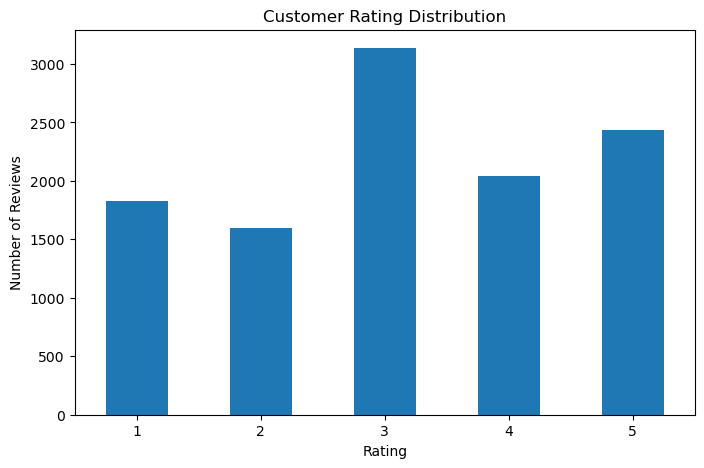

In [136]:
plt.figure(figsize=(8,5))

rating_counts.plot(kind='bar')

plt.title('Customer Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

## Inference:
The rating distribution shows that customer experiences are mixed, with reviews spread across all five rating categories 1 star and 2 star indicates meaningful portion of customers have experienced problems with the application Meanwhile 3-star reviews have the highest frequency in the dataset

## Insights
The company should prioritize the 1- and 2-star reviews because they represent customers with the highest dissatisfaction and provide an opportunity to identify recurring product or service issues 

In [137]:
df['review_category'] = df['score'].apply(
    lambda x: 'Critical' if x in [1, 2] else 'Non-Critical'
)

category_counts = df['review_category'].value_counts()
category_counts

review_category
Non-Critical    7611
Critical        3423
Name: count, dtype: int64

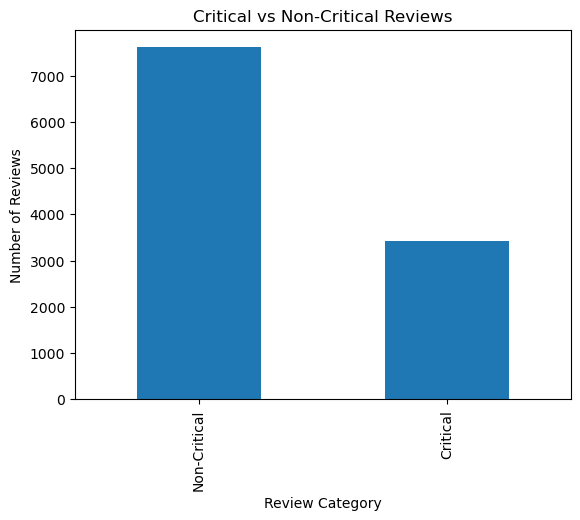

In [138]:
category_counts.plot(kind='bar')
plt.title('Critical vs Non-Critical Reviews')
plt.xlabel('Review Category')
plt.ylabel('Number of Reviews')
plt.show()

## Inference:-
The graph compares critical reviews, defined as 1–2 star ratings, with all other reviews. It shows the scale of negative customer feedback within the dataset and indicates how large the group is that may require customer-support attention.

## Insights:-
Instead of manually reviewing all customer feedback, the company can prioritize the critical segment first, reducing the workload for the support team.

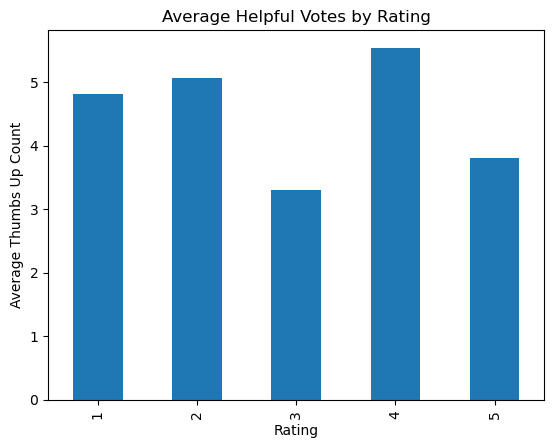

In [139]:
avg_helpful = df.groupby('score')['thumbsUpCount'].mean()

avg_helpful.plot(kind='bar')
plt.title('Average Helpful Votes by Rating')
plt.xlabel('Rating')
plt.ylabel('Average Thumbs Up Count')
plt.show()

## Inference:-
The higher helpful-vote average for 4-star reviews suggests that moderately positive reviews generate relatively strong engagement from other users. Meanwhile, 3-star reviews receive the lowest average engagement in this dataset.

## Insights:-
The company should not focus exclusively on negative reviews when learning from customers. Highly engaged 4-star reviews may contain detailed and useful feedback that can reveal what users value and where further improvements are possible.

## Review Length Analysis

In [140]:
df['review_length'] = df['clean_content'].str.len()
df

,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appId,clean_content,review_category,review_length
reviewId,,,,,,,,,,,,
gp:AOqpTOHNHm4OfbjkxEXXa51JwZEHAaDlvfSgN0OU256pfT7428KsbH9tjw7KKDqj-1BmR17grIB-V4ek0tcsJw,Lex S,"I love this app, but I do have one major gripe...",1,3,5.2.0.23,2020-08-05 16:22:04,Any.do is not only a product but also a servic...,2020-08-05 08:02:08,com.anydo,i love this app but i do have one major gripe ...,Critical,366
gp:AOqpTOEujjLj56XVqumAkipImEqIAU3qTIuQjENPaOKw6pLkwzyb3GERvPeldV6GdYZjjmPFP5xzKfcAWt-7Dg,Sam van Dijk,"Trash. Yes, it has some nice nifty features bu...",1,25,5.2.0.23,2020-07-21 22:17:25,"Premium users can edit, create and delete tags...",2020-07-23 15:57:51,com.anydo,trash yes it has some nice nifty features but ...,Critical,472
gp:AOqpTOElISilniODwd6UBrqFngzTtDHLF-G0VLpR2_y1sV7IzvZ1DseLe4E2ZNiuQzrUc0To12jF9rMqIY0Fvg,Hugo Bounoua,"OMG the UI is awful, seriously you have popup ...",1,8,5.2.0.23,2020-07-22 07:23:35,The Premium ad only shows up when first openin...,2020-07-23 16:20:43,com.anydo,omg the ui is awful seriously you have popup f...,Critical,300
gp:AOqpTOEkZ75JR5CzVhxoxWa0XVmPanw_pEl1srcJ7yvkZdkPV4XNyXxE4R2fnG82e6qeXd7mhDYsfPYz5hh08A,Aishwarya Mishra,I've been using the app for a while and since ...,1,20,5.2.0.23,2020-07-19 06:49:15,"Hi, due to new restrictions from Google, the p...",2020-07-22 14:05:56,com.anydo,i ve been using the app for a while and since ...,Critical,195
gp:AOqpTOEtpLcODD_NZOBqR1N7DBbaLdw3Gyz3v3xZAp19HgHc4QKSUlOZSrGzvZP6Kqdyp3Gzea5ClRMAAR97LA,Mad Scientist,"Unable to register with an email. Clicking""con...",1,77,5.2.0.9,2020-07-10 17:59:22,We are unaware of any issues with signing in t...,2020-07-12 08:02:19,com.anydo,unable to register with an email clicking cont...,Critical,338
...,...,...,...,...,...,...,...,...,...,...,...,...
gp:AOqpTOFHtL0Ia2KwJwdPNSHbR9LGshVnjARvr_I07obs_a88dGpoUXMwfNT2zEtc9al1Fb9Y_PK-2Aqz_VbCHA,Sebastian Gawlik,Great planer,5,0,5.0.2,2020-06-22 17:38:32,No Reply,NaT,com.appxy.planner,great planer,Non-Critical,12
gp:AOqpTOEdeLQjiyHTH91cN0qSiTqO_bad0UkIvqt6521VFKQgU6DUEtHYTBAyoNAhmf2sQEwvEpWbyP5sFuWPZA,Osbaldo Garza,5 stars,5,0,5.0.2,2020-06-22 16:34:42,No Reply,NaT,com.appxy.planner,stars,Non-Critical,5
gp:AOqpTOFNY13YXBEvNWzEeP_gu3YjebTWw1xXTVvMUswWCnArQp2jFkcA-OOq71UwvoriYMCEiIjMBsumvGNshw,Soyaras Turner,Very helpful,5,0,5.0.2,2020-06-22 05:20:30,No Reply,NaT,com.appxy.planner,very helpful,Non-Critical,12


In [141]:
df['review_length'].describe()

count    11034.000000
mean       175.230288
std        152.366231
min          0.000000
25%         55.000000
50%        131.000000
75%        263.000000
max       2118.000000
Name: review_length, dtype: float64

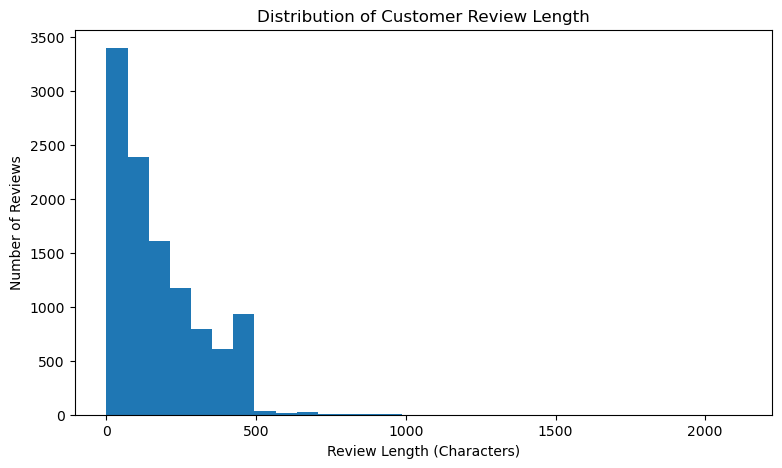

In [142]:
plt.figure(figsize=(9, 5))

plt.hist(
    df['review_length'],
    bins=30
)

plt.title('Distribution of Customer Review Length')
plt.xlabel('Review Length (Characters)')
plt.ylabel('Number of Reviews')

plt.show()

## Inference:-
Most customer reviews are relatively short, while a smaller number of reviews are substantially longer. The mean being higher than the median indicates a right-skewed distribution caused by these longer reviews

## Insights:-
The company must see most feedback is concise and the smaller group of detailed reviews may contain richer information about specific customer problems and should be considered during deeper complaint analysis.

In [143]:
avg_length_by_rating = (df.groupby('score')['review_length'].mean())
print(avg_length_by_rating)

score
1    166.469846
2    202.323327
3    176.791454
4    184.978963
5    153.772110
Name: review_length, dtype: float64


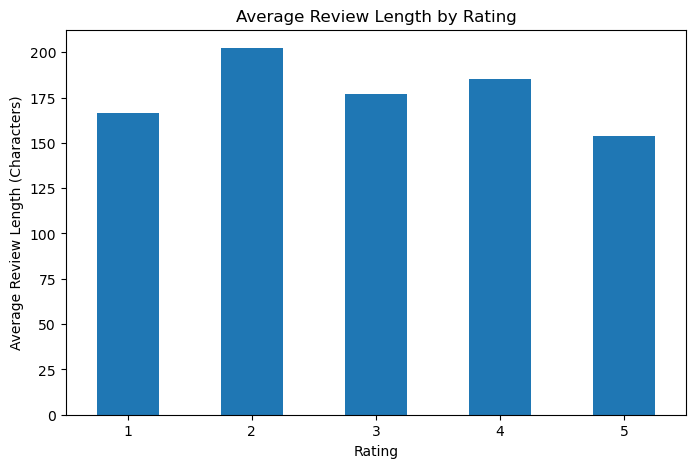

In [144]:
plt.figure(figsize=(8, 5))
avg_length_by_rating.plot(kind='bar')

plt.title('Average Review Length by Rating')
plt.xlabel('Rating')
plt.ylabel('Average Review Length (Characters)')
plt.xticks(rotation=0)

plt.show()

## Inference:-
The graph suggests that customers giving 2-star ratings tend to provide more detailed written feedback than customers giving other ratings. This indicates that moderately negative experiences may be described in greater detail, potentially providing more information about specific problems.

## Insights:-
The company should pay particular attention to detailed 2-star reviews because they may contain specific explanations of customer problems and actionable feedback. These reviews can be valuable for identifying recurring complaints and improvement opportunities.

In [145]:
critical_reviews = df[df['score'].isin([1, 2])].copy() # select the critical reviews

critical_reviews['review_length'] = (
    critical_reviews['clean_content'].str.len() # calculated the critial reviews 
)
critical_reviews

,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appId,clean_content,review_category,review_length
reviewId,,,,,,,,,,,,
gp:AOqpTOHNHm4OfbjkxEXXa51JwZEHAaDlvfSgN0OU256pfT7428KsbH9tjw7KKDqj-1BmR17grIB-V4ek0tcsJw,Lex S,"I love this app, but I do have one major gripe...",1,3,5.2.0.23,2020-08-05 16:22:04,Any.do is not only a product but also a servic...,2020-08-05 08:02:08,com.anydo,i love this app but i do have one major gripe ...,Critical,366
gp:AOqpTOEujjLj56XVqumAkipImEqIAU3qTIuQjENPaOKw6pLkwzyb3GERvPeldV6GdYZjjmPFP5xzKfcAWt-7Dg,Sam van Dijk,"Trash. Yes, it has some nice nifty features bu...",1,25,5.2.0.23,2020-07-21 22:17:25,"Premium users can edit, create and delete tags...",2020-07-23 15:57:51,com.anydo,trash yes it has some nice nifty features but ...,Critical,472
gp:AOqpTOElISilniODwd6UBrqFngzTtDHLF-G0VLpR2_y1sV7IzvZ1DseLe4E2ZNiuQzrUc0To12jF9rMqIY0Fvg,Hugo Bounoua,"OMG the UI is awful, seriously you have popup ...",1,8,5.2.0.23,2020-07-22 07:23:35,The Premium ad only shows up when first openin...,2020-07-23 16:20:43,com.anydo,omg the ui is awful seriously you have popup f...,Critical,300
gp:AOqpTOEkZ75JR5CzVhxoxWa0XVmPanw_pEl1srcJ7yvkZdkPV4XNyXxE4R2fnG82e6qeXd7mhDYsfPYz5hh08A,Aishwarya Mishra,I've been using the app for a while and since ...,1,20,5.2.0.23,2020-07-19 06:49:15,"Hi, due to new restrictions from Google, the p...",2020-07-22 14:05:56,com.anydo,i ve been using the app for a while and since ...,Critical,195
gp:AOqpTOEtpLcODD_NZOBqR1N7DBbaLdw3Gyz3v3xZAp19HgHc4QKSUlOZSrGzvZP6Kqdyp3Gzea5ClRMAAR97LA,Mad Scientist,"Unable to register with an email. Clicking""con...",1,77,5.2.0.9,2020-07-10 17:59:22,We are unaware of any issues with signing in t...,2020-07-12 08:02:19,com.anydo,unable to register with an email clicking cont...,Critical,338
...,...,...,...,...,...,...,...,...,...,...,...,...
gp:AOqpTOGuX9anI8XNo3mVcQsrdg3m427F0dztp83Y4cg7tKsPKhi7_G0lnNIXlmE0XGFSed51Dn2sI8W-9z2muQ,Maze T,It has deleted all of my entries planned for t...,2,0,3.2.3,2017-01-15 20:40:59,No Reply,NaT,com.appxy.planner,it has deleted all of my entries planned for t...,Critical,78
gp:AOqpTOGURnYbC96NGZRCuSZFyfEZ_KObWReNI2dWn-aoQq8VUezBs0oj8KCrNigBGatCF33CX1S_u4wm6wAkpQ,B. Blue Marble,I installed because of the option to synch tas...,2,0,Unknown,2016-12-21 05:11:03,No Reply,NaT,com.appxy.planner,i installed because of the option to synch tas...,Critical,233
gp:AOqpTOEUnpBwRHs3JgNK8k8Lpb8n6N4yxd6En7zRwyRH15wtX_ERz0DYiKsicJdakihxUeaNgrdpv-TObXrShA,Tyler Meers,"Very easy to pull me in I should have stopped,...",2,0,Unknown,2016-12-14 21:33:40,No Reply,NaT,com.appxy.planner,very easy to pull me in i should have stopped ...,Critical,494


In [146]:
# Identifing the long Critical Reviews
detailed_critical = critical_reviews.sort_values('review_length',ascending=False)
detailed_critical[['score', 'review_length', 'content']].head(10)

,score,review_length,content
reviewId,,,
gp:AOqpTOGd__CCVzvUxvCnTr7jC6J9bSvc6uPCR6XfH10vPaR0H8OIGEdx_Z2hFKfJOY1QKbbe2rVYlFV3cktCQNY,2,1272,After being forced to move from simple and gre...
gp:AOqpTOEd08lQkw21nbgIr0bPfUXa8M3Or1dNJ7VunTkiB87_q3tv_DsIGI3RLmJcfN0d3Qassm9m76QfbHgQFe8,1,1244,Ads that cover the whole screen [Later update]...
gp:AOqpTOHcRertDnHPkoo_0DoAJgiwjEL68CYvpge2K2cS63_M5HHx3fjnnFggJKXXw6Ey8RgVExQUllWjyEWqfg,1,1066,Requires account to use. I was just giving a...
gp:AOqpTOHfHJZ74EiWGxOlFoFqIkgNevu1tPZ9G6RtCUvFcnDkyVRP3yDL0XsLm5wkG97tLKVnU3OK4zED_FCec1k,2,975,Checked out this app in my quest to find a goo...
gp:AOqpTOEvgnagXL0q-gMuNfZTiimdZNT3A54qzb8sUJJBCg3mcu_HvQq30Iv9NmlhIPo_HXzSwFv11gYXUVlxMQ,2,959,I am trying to find a decent replacement for W...
gp:AOqpTOH8Pj3I0Qb5jcI9IPRZMdTrU0wgn2VXpkULvRbY3JMQqLAqIP3odOp70K5F5v-Oi8-QAXyP0TlcGID29Q,2,957,Deleted review accidentally. 1. I create habit...
gp:AOqpTOGYKKItqT647GyS4xL88-1sts026PPn8dFxHzuqPXUwwhK9dU1YL3jlVOeoUQmtkPJodzKBJYQG7KPE4w4,2,932,Very nice app with a bad drawback: today's rep...
gp:AOqpTOEzmcFcphSf0dSFT_qxdXSqEnIFZWCVnWHQyuCuyu1YaI3FcuThDfY1hTRVJhEeK0MIcqqBT3eABRNiWQ,2,915,"Well, based on the description of this app and..."
gp:AOqpTOGZSdRx8TEwZiLG7-LC4V1ELWTBRNZ99l7kySCslydaRvLX8VlFSKK6XO5PkiyJfKWtgzebBLt9gOvU3ho,2,870,"I really like this app, it's one of the best r..."


In [147]:
long_critical = critical_reviews[
    critical_reviews['review_length'] > 573.5
]

print("Long critical reviews:", len(long_critical))
percentage = (
    len(long_critical) /
    len(critical_reviews)
) * 100

print(f"{percentage:.2f}% of critical reviews are unusually long.")

Long critical reviews: 28
0.82% of critical reviews are unusually long.


In [150]:
# its is basically the word counter
from collections import Counter
all_critical_text = " ".join(
    critical_reviews['clean_content']
)

words = all_critical_text.split()
word_counts = Counter(words)
word_counts.most_common(20)

[('the', 4920),
 ('i', 4658),
 ('to', 4319),
 ('it', 3501),
 ('app', 2637),
 ('and', 2499),
 ('a', 2398),
 ('is', 1755),
 ('for', 1737),
 ('this', 1700),
 ('t', 1621),
 ('my', 1411),
 ('but', 1339),
 ('not', 1335),
 ('of', 1307),
 ('you', 1149),
 ('that', 1104),
 ('in', 1025),
 ('have', 957),
 ('on', 898)]

In [186]:
#removing the unhelpful words
stop_words = {
    # Common English words
    'the', 'i', 'to', 'it', 'and', 'a', 'is', 'for', 'this',
    'my', 'but', 'not', 'of', 'you', 'that', 'in', 'have',
    'on', 'with', 'can', 'was', 'all', 'use', 'time', 'just',
    'when', 'now', 'be', 'are', 'am', 'an', 'as', 'at', 'by',
    'from', 'or', 'so', 'if', 'they', 'them', 'their', 'there',
    'what', 'which', 'who', 'how', 'why', 'we', 'our', 'your',
    'me', 'he', 'she', 'his', 'her', 'were', 'been', 'being',
    'do', 'does', 'did', 'doing', 'would', 'could', 'should',
    'will', 'just', 'very', 'more', 'most', 'some', 'any',
    'than', 'then', 'also', 'only', 'really', 'much', 'many',
    'other', 'another', 'still', 'even', 'thing', 'things',
    'way', 'want', 'need', 'out', 'up', 'down', 'about',
    'after', 'before', 'because', 'into', 'over', 'under',
    'again', 'here', 'there', 'these', 'those', 'such',
    
    # Common review-language words
    'app', 'apps', 'get', 'got', 'getting', 'make', 'made',
    'like', 'liked', 'good', 'great', 'please', 'now',
    'new', 'first', 'one', 'two', 'free', 'well', 'work',
    'works', 'working', 'used', 'using', 'dont', 'doesnt',
    'didnt', 'cant', 'couldnt', 'wouldnt', 'wont',
    'shouldnt', 'didn', 'doesn', 'don', 'didnt'
}

meaningful_words = [
    word for word in words
    if word not in stop_words
    and len(word) > 2
]

complaint_counts = Counter(meaningful_words)
complaint_counts.most_common(20)

[('tasks', 460),
 ('calendar', 440),
 ('version', 394),
 ('task', 372),
 ('list', 351),
 ('day', 337),
 ('premium', 327),
 ('has', 303),
 ('phone', 303),
 ('sync', 275),
 ('update', 272),
 ('google', 252),
 ('had', 245),
 ('set', 227),
 ('ads', 222),
 ('widget', 216),
 ('add', 211),
 ('every', 207),
 ('pay', 204),
 ('reminders', 201)]

In [187]:
# Top Keyword Graphs
top_complaints = complaint_counts.most_common(10)
complaint_df = pd.DataFrame(
    top_complaints,
    columns=['Keyword', 'Count']
)
complaint_df

,Keyword,Count
0,tasks,460
1,calendar,440
2,version,394
3,task,372
4,list,351
5,day,337
6,premium,327
7,has,303
8,phone,303
9,sync,275


In [188]:
#Single-word frequency
word_normalization = {
    'tasks': 'task'
}

normalized_words = [
    word_normalization.get(word, word)
    for word in meaningful_words
]

complaint_counts = Counter(normalized_words)

complaint_counts.most_common(20)

[('task', 832),
 ('calendar', 440),
 ('version', 394),
 ('list', 351),
 ('day', 337),
 ('premium', 327),
 ('has', 303),
 ('phone', 303),
 ('sync', 275),
 ('update', 272),
 ('google', 252),
 ('had', 245),
 ('set', 227),
 ('ads', 222),
 ('widget', 216),
 ('add', 211),
 ('every', 207),
 ('pay', 204),
 ('reminders', 201),
 ('features', 198)]

In [189]:
#Normalized keyword frequency
from collections import Counter

bigrams = list(zip(
    normalized_words,
    normalized_words[1:]
))

bigram_counts = Counter(bigrams)

bigram_counts.most_common(30)

[(('pro', 'version'), 94),
 (('google', 'calendar'), 91),
 (('premium', 'version'), 64),
 (('full', 'screen'), 47),
 (('recurring', 'task'), 37),
 (('paid', 'premium'), 35),
 (('completed', 'task'), 34),
 (('every', 'day'), 34),
 (('paid', 'version'), 32),
 (('user', 'friendly'), 30),
 (('recent', 'update'), 30),
 (('add', 'task'), 29),
 (('task', 'list'), 29),
 (('keeps', 'crashing'), 28),
 (('next', 'day'), 27),
 (('latest', 'update'), 26),
 (('due', 'date'), 26),
 (('bought', 'premium'), 26),
 (('daily', 'task'), 25),
 (('screen', 'ads'), 25),
 (('last', 'update'), 24),
 (('google', 'account'), 24),
 (('google', 'task'), 24),
 (('customer', 'service'), 23),
 (('full', 'version'), 23),
 (('set', 'reminder'), 21),
 (('sync', 'google'), 21),
 (('home', 'screen'), 21),
 (('business', 'calendar'), 20),
 (('buy', 'pro'), 20)]

In [190]:
#Two-word/bigram frequency
meaningful_bigrams = [
    (word1, word2)
    for word1, word2 in bigrams
    if word1 not in stop_words
    and word2 not in stop_words
    and len(word1) > 2
    and len(word2) > 2
]

bigram_counts = Counter(meaningful_bigrams)
bigram_counts.most_common(30)

[(('pro', 'version'), 94),
 (('google', 'calendar'), 91),
 (('premium', 'version'), 64),
 (('full', 'screen'), 47),
 (('recurring', 'task'), 37),
 (('paid', 'premium'), 35),
 (('completed', 'task'), 34),
 (('every', 'day'), 34),
 (('paid', 'version'), 32),
 (('user', 'friendly'), 30),
 (('recent', 'update'), 30),
 (('add', 'task'), 29),
 (('task', 'list'), 29),
 (('keeps', 'crashing'), 28),
 (('next', 'day'), 27),
 (('latest', 'update'), 26),
 (('due', 'date'), 26),
 (('bought', 'premium'), 26),
 (('daily', 'task'), 25),
 (('screen', 'ads'), 25),
 (('last', 'update'), 24),
 (('google', 'account'), 24),
 (('google', 'task'), 24),
 (('customer', 'service'), 23),
 (('full', 'version'), 23),
 (('set', 'reminder'), 21),
 (('sync', 'google'), 21),
 (('home', 'screen'), 21),
 (('business', 'calendar'), 20),
 (('buy', 'pro'), 20)]

In [191]:
reviews_by_year = (
    df.groupby(df['at'].dt.year)
      .size()
)

reviews_by_year

at
2014       2
2015      49
2016     154
2017     173
2018     720
2019    2338
2020    7598
dtype: int64

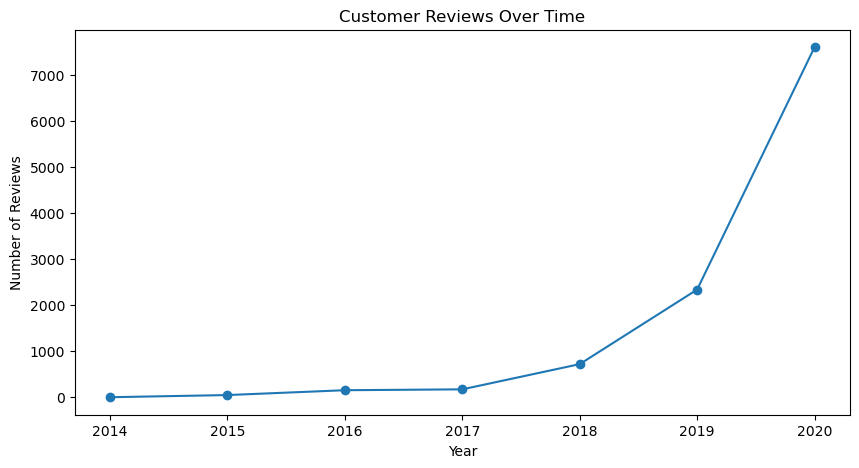

In [192]:
plt.figure(figsize=(10, 5))

reviews_by_year.plot(
    kind='line',
    marker='o'
)

plt.title('Customer Reviews Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')

plt.show()

## Inference :-
The dataset shows a strong increase in customer feedback activity over the years, particularly from 2018 onward. This indicates that the volume of customer feedback grew considerably during the later years of the dataset.

## Insights
As review volume increases, manually monitoring every customer review becomes increasingly difficult. This supports the need for an automated process to filter and prioritize important feedback.

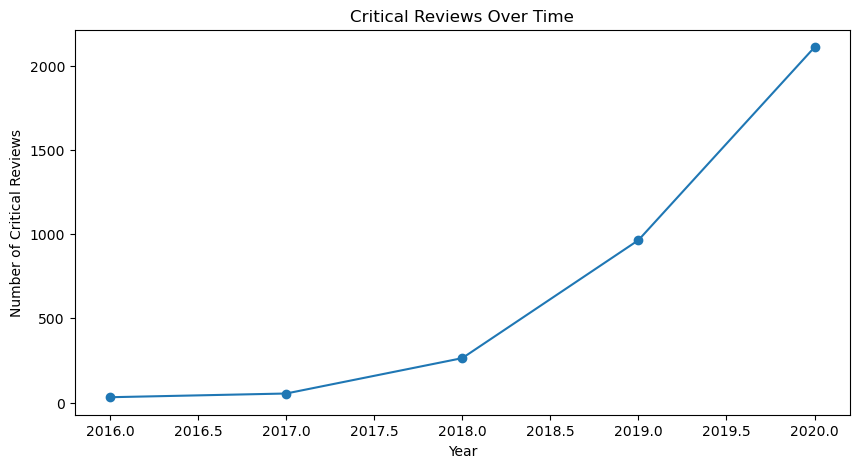

In [193]:
critical_by_year = (
    critical_reviews.groupby(
        critical_reviews['at'].dt.year
    ).size()
)

critical_by_year
plt.figure(figsize=(10, 5))

critical_by_year.plot(
    kind='line',
    marker='o'
)

plt.title('Critical Reviews Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Critical Reviews')

plt.show()

## Inference:-
The volume of critical feedback increased considerably during the later years of the dataset. However, because the total number of reviews also increased sharply over the same period, the rise in critical-review count alone does not prove that customer satisfaction deteriorated.

## Insights:-
The growing volume of critical reviews increases the workload associated with identifying and responding to dissatisfied customers. A rule-based system can automatically isolate 1- and 2-star reviews so that support teams can prioritize them efficiently.

In [194]:
yearly_summary = (
    df.assign(
        year=df['at'].dt.year,
        is_critical=df['score'].isin([1, 2])
    )
    .groupby('year')
    .agg(
        total_reviews=('score', 'size'),
        critical_reviews=('is_critical', 'sum')
    )
)

yearly_summary['critical_percentage'] = (
    yearly_summary['critical_reviews']
    / yearly_summary['total_reviews']
    * 100
)

yearly_summary

,total_reviews,critical_reviews,critical_percentage
year,,,
2014,2,0,0.000000
2015,49,0,0.000000
2016,154,32,20.779221
2017,173,54,31.213873
2018,720,264,36.666667
2019,2338,964,41.231822
2020,7598,2109,27.757305


In [195]:
critical_candidates = critical_reviews.sort_values(
    by=['score', 'review_length'],
    ascending=[True, False]
)

critical_candidates[
    ['score', 'review_length', 'content']
].head(20)

,score,review_length,content
reviewId,,,
gp:AOqpTOEd08lQkw21nbgIr0bPfUXa8M3Or1dNJ7VunTkiB87_q3tv_DsIGI3RLmJcfN0d3Qassm9m76QfbHgQFe8,1,1244,Ads that cover the whole screen [Later update]...
gp:AOqpTOHcRertDnHPkoo_0DoAJgiwjEL68CYvpge2K2cS63_M5HHx3fjnnFggJKXXw6Ey8RgVExQUllWjyEWqfg,1,1066,Requires account to use. I was just giving a...
gp:AOqpTOFddNJuP9q7s8DuAlM9aYYncAzV0_3RLOBRtQahOyogLNtNeeuUQGxvM_behYxyhjSap2aH6KW5VSX82w,1,866,I was a customer of Any.Do for a while and on ...
gp:AOqpTOH8c38kBqW5xCnZbDcIWS_IgN6jiWwtwJwoRSbPbeQMTdznS1snW85Tix0MTtyq0el8G2PfAcRY7-vszA,1,696,**UPDATE**. I uninstalled this app. It now cau...
gp:AOqpTOG5pBwlrPztEN20mKUg9s_TwPBbz5gfQ0uY0CGDy7YwPTezubuS39NQMm7NsYXJTPhHFE5clcVSnB5yKQ,1,648,Used to be simple well organized app. Latest u...
gp:AOqpTOFe9GGiEE683Qw6l8F9g5f0CMMhN_yyj5CYzjqLUcsXVLy5IvqoxzgJ-S-LoihepPV0k_gRzdhNwerMEn4,1,647,Updating my previous review. I recently hit th...
gp:AOqpTOF4k6LvfI4bYNQqJ6bk4j0MTkofB3KDgu8f6d_OCktK9nxNm2kHXvMtXLgE0h9WkPs0f2pyBmkm7DCkdEE,1,623,I have used this after being forced to migrate...
gp:AOqpTOEiQAAF8g6q3XzB1MpRXaARWqcs7Mm0TuQuHUZYufOLuRVRvlWDCcAj73j6R7V_qJkGWzOvyYr6pL0AEQ,1,547,Edit: Still doesn't work. I suggest adding pro...
gp:AOqpTOFfMyTX1TSXNnnXrCbMWOBS11ny_48HAKLZkZVUFwz24j56_HhZ2B9gvZW4BRNB59sZie_V4sC5R9Fbag,1,543,I missed my work today because of your stupid ...


In [196]:
critical_candidates[
    ['score', 'review_length', 'content']
].head(20).to_string(index=False)

' score  review_length                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [197]:
selected_reviews = critical_candidates.iloc[[0, 1, 2]].copy()

In [198]:
critical_candidates = critical_reviews.sort_values(
    by=['score', 'review_length'],
    ascending=[True, False]
)

critical_candidates[
    ['score', 'review_length', 'content']
].head(20).to_string(index=False)

' score  review_length                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [199]:
critical_candidates[
    ['score', 'review_length', 'content']
].head(20).to_string(index=False)

' score  review_length                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [200]:
critical_candidates[
    ['score', 'review_length', 'content']
].head(10)

,score,review_length,content
reviewId,,,
gp:AOqpTOEd08lQkw21nbgIr0bPfUXa8M3Or1dNJ7VunTkiB87_q3tv_DsIGI3RLmJcfN0d3Qassm9m76QfbHgQFe8,1,1244,Ads that cover the whole screen [Later update]...
gp:AOqpTOHcRertDnHPkoo_0DoAJgiwjEL68CYvpge2K2cS63_M5HHx3fjnnFggJKXXw6Ey8RgVExQUllWjyEWqfg,1,1066,Requires account to use. I was just giving a...
gp:AOqpTOFddNJuP9q7s8DuAlM9aYYncAzV0_3RLOBRtQahOyogLNtNeeuUQGxvM_behYxyhjSap2aH6KW5VSX82w,1,866,I was a customer of Any.Do for a while and on ...
gp:AOqpTOH8c38kBqW5xCnZbDcIWS_IgN6jiWwtwJwoRSbPbeQMTdznS1snW85Tix0MTtyq0el8G2PfAcRY7-vszA,1,696,**UPDATE**. I uninstalled this app. It now cau...
gp:AOqpTOG5pBwlrPztEN20mKUg9s_TwPBbz5gfQ0uY0CGDy7YwPTezubuS39NQMm7NsYXJTPhHFE5clcVSnB5yKQ,1,648,Used to be simple well organized app. Latest u...
gp:AOqpTOFe9GGiEE683Qw6l8F9g5f0CMMhN_yyj5CYzjqLUcsXVLy5IvqoxzgJ-S-LoihepPV0k_gRzdhNwerMEn4,1,647,Updating my previous review. I recently hit th...
gp:AOqpTOF4k6LvfI4bYNQqJ6bk4j0MTkofB3KDgu8f6d_OCktK9nxNm2kHXvMtXLgE0h9WkPs0f2pyBmkm7DCkdEE,1,623,I have used this after being forced to migrate...
gp:AOqpTOEiQAAF8g6q3XzB1MpRXaARWqcs7Mm0TuQuHUZYufOLuRVRvlWDCcAj73j6R7V_qJkGWzOvyYr6pL0AEQ,1,547,Edit: Still doesn't work. I suggest adding pro...
gp:AOqpTOFfMyTX1TSXNnnXrCbMWOBS11ny_48HAKLZkZVUFwz24j56_HhZ2B9gvZW4BRNB59sZie_V4sC5R9Fbag,1,543,I missed my work today because of your stupid ...


In [201]:
critical_candidates[
    ['score', 'review_length', 'content']
].head(10).reset_index()

,reviewId,score,review_length,content
0,gp:AOqpTOEd08lQkw21nbgIr0bPfUXa8M3Or1dNJ7VunTk...,1,1244,Ads that cover the whole screen [Later update]...
1,gp:AOqpTOHcRertDnHPkoo_0DoAJgiwjEL68CYvpge2K2c...,1,1066,Requires account to use. I was just giving a...
2,gp:AOqpTOFddNJuP9q7s8DuAlM9aYYncAzV0_3RLOBRtQa...,1,866,I was a customer of Any.Do for a while and on ...
3,gp:AOqpTOH8c38kBqW5xCnZbDcIWS_IgN6jiWwtwJwoRSb...,1,696,**UPDATE**. I uninstalled this app. It now cau...
4,gp:AOqpTOG5pBwlrPztEN20mKUg9s_TwPBbz5gfQ0uY0CG...,1,648,Used to be simple well organized app. Latest u...
5,gp:AOqpTOFe9GGiEE683Qw6l8F9g5f0CMMhN_yyj5CYzjq...,1,647,Updating my previous review. I recently hit th...
6,gp:AOqpTOF4k6LvfI4bYNQqJ6bk4j0MTkofB3KDgu8f6d_...,1,623,I have used this after being forced to migrate...
7,gp:AOqpTOEiQAAF8g6q3XzB1MpRXaARWqcs7Mm0TuQuHUZ...,1,547,Edit: Still doesn't work. I suggest adding pro...
8,gp:AOqpTOFfMyTX1TSXNnnXrCbMWOBS11ny_48HAKLZkZV...,1,543,I missed my work today because of your stupid ...
9,gp:AOqpTOFXsi_swykv0PpeW0FXXa_48YMyKKAgKYpZ0sX...,1,537,"This app is very, very, very sexist. When you ..."


In [202]:
selected_reviews

,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appId,clean_content,review_category,review_length
reviewId,,,,,,,,,,,,
gp:AOqpTOEd08lQkw21nbgIr0bPfUXa8M3Or1dNJ7VunTkiB87_q3tv_DsIGI3RLmJcfN0d3Qassm9m76QfbHgQFe8,Alin Posorovaschi,Ads that cover the whole screen [Later update]...,1,0,2.32.2,2020-06-26 11:47:00,"Hi, we avoided this solution for as long as it...",2020-07-06 13:11:34,com.appgenix.bizcal,ads that cover the whole screen later update s...,Critical,1244
gp:AOqpTOHcRertDnHPkoo_0DoAJgiwjEL68CYvpge2K2cS63_M5HHx3fjnnFggJKXXw6Ey8RgVExQUllWjyEWqfg,Dave Spiegel,Requires account to use. I was just giving a...,1,0,Unknown,2019-07-08 17:40:47,"Dave, that's true, within 10 seconds you can s...",2019-07-08 15:01:16,com.todoist,requires account to use i was just giving a si...,Critical,1066
gp:AOqpTOFddNJuP9q7s8DuAlM9aYYncAzV0_3RLOBRtQahOyogLNtNeeuUQGxvM_behYxyhjSap2aH6KW5VSX82w,Amir Ben Aroia,I was a customer of Any.Do for a while and on ...,1,1,5.2.0.9,2020-06-18 10:45:55,Our Support Team has already addressed this Am...,2020-06-21 11:24:39,com.anydo,i was a customer of any do for a while and on ...,Critical,866


In [203]:
selected_reviews[
    ['userName', 'score', 'review_length', 'content']
].to_string(index=False)

'         userName  score  review_length                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [204]:
print("Number of selected reviews:", len(selected_reviews))
print("\nRatings:")
print(selected_reviews['score'].value_counts())

Number of selected reviews: 3

Ratings:
score
1    3
Name: count, dtype: int64


In [205]:
#Reviewing the Each ID 
selected_reviews = selected_reviews.copy()

selected_reviews['case_id'] = [
    'Critical Review 1',
    'Critical Review 2',
    'Critical Review 3'
]

In [206]:
selected_reviews[['case_id', 'score', 'review_length', 'content']]

,case_id,score,review_length,content
reviewId,,,,
gp:AOqpTOEd08lQkw21nbgIr0bPfUXa8M3Or1dNJ7VunTkiB87_q3tv_DsIGI3RLmJcfN0d3Qassm9m76QfbHgQFe8,Critical Review 1,1,1244,Ads that cover the whole screen [Later update]...
gp:AOqpTOHcRertDnHPkoo_0DoAJgiwjEL68CYvpge2K2cS63_M5HHx3fjnnFggJKXXw6Ey8RgVExQUllWjyEWqfg,Critical Review 2,1,1066,Requires account to use. I was just giving a...
gp:AOqpTOFddNJuP9q7s8DuAlM9aYYncAzV0_3RLOBRtQahOyogLNtNeeuUQGxvM_behYxyhjSap2aH6KW5VSX82w,Critical Review 3,1,866,I was a customer of Any.Do for a while and on ...


## Gen Ai Part:-

In [207]:
!pip install openai

## Importing Libraries

In [208]:
from openai import OpenAI
import os

In [209]:
os.environ["OPENAI_API_KEY"] = ""

In [210]:
import os
from getpass import getpass

os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

Enter your OpenAI API key:  ········


In [211]:
from openai import OpenAI

client = OpenAI()

In [212]:
def generate_customer_response(review):

    prompt = f"""
You are a professional customer support agent.

A customer has submitted the following negative review:

Customer Review:
{review}

Write a short, personalized and empathetic apology email.

Requirements:
- Address the customer's specific complaint.
- Acknowledge the customer's frustration.
- Be professional and empathetic.
- Keep the response concise.
- Do not invent refunds, discounts, compensation, or actions.
- Do not make promises that are not supported by the review.
- Do not mention AI.
- End with a professional customer-support closing.

Return only the email.
"""

    response = client.responses.create(
        model="gpt-6-luna",
        input=prompt
    )

    return response.output_text

In [213]:
review_1 = selected_reviews.iloc[0]['content']

response_1 = generate_customer_response(review_1)

print(response_1)

Subject: We’re sorry about the full-screen ads

Hi,

I’m sorry the full-screen game ads disrupted your use of Business Calendar and made you question the app’s safety. I understand how frustrating it is to have ads you can’t easily skip—especially in a business app—and to feel that recent changes have reduced its value.

Thank you for explaining your concerns. We’re sorry this experience has let you down.

Best regards,  
Customer Support



In [214]:
selected_reviews['AI_Response'] = selected_reviews['content'].apply(
    generate_customer_response
)

In [215]:
for i, row in selected_reviews.iterrows():
    print("=" * 80)
    print(f"Customer: {row['userName']}")
    print(f"Rating: {row['score']}")
    print("-" * 80)
    print(row['AI_Response'])
    print()

Customer: Alin Posorovaschi
Rating: 1
--------------------------------------------------------------------------------
Hi,

I’m sorry the full-screen game ads have disrupted your use of Business Calendar and made you question the app’s trustworthiness. I understand how frustrating it is to have irrelevant ads interrupt a business tool—and that you’d prefer a stable version with fewer or no ads.

Thank you for explaining how this has affected your experience. I’m sorry we’ve made the app feel less useful than the calendar already on your devices.

Best regards,  
Business Calendar Support

Customer: Dave Spiegel
Rating: 1
--------------------------------------------------------------------------------
Hi,

I’m sorry our earlier response dismissed your concern. You wanted a simple task list without being required to create an account or share your information, and I understand how frustrating it is to feel that choice wasn’t respected. Thank you for explaining your perspective, and I’m g

In [216]:
final_output = selected_reviews[
    ['userName', 'score', 'content', 'AI_Response']
].copy()

final_output.columns = [
    'Customer',
    'Rating',
    'Original Review',
    'AI Generated Response'
]

final_output

,Customer,Rating,Original Review,AI Generated Response
reviewId,,,,
gp:AOqpTOEd08lQkw21nbgIr0bPfUXa8M3Or1dNJ7VunTkiB87_q3tv_DsIGI3RLmJcfN0d3Qassm9m76QfbHgQFe8,Alin Posorovaschi,1,Ads that cover the whole screen [Later update]...,"Hi,\n\nI’m sorry the full-screen game ads have..."
gp:AOqpTOHcRertDnHPkoo_0DoAJgiwjEL68CYvpge2K2cS63_M5HHx3fjnnFggJKXXw6Ey8RgVExQUllWjyEWqfg,Dave Spiegel,1,Requires account to use. I was just giving a...,"Hi,\n\nI’m sorry our earlier response dismisse..."
gp:AOqpTOFddNJuP9q7s8DuAlM9aYYncAzV0_3RLOBRtQahOyogLNtNeeuUQGxvM_behYxyhjSap2aH6KW5VSX82w,Amir Ben Aroia,1,I was a customer of Any.Do for a while and on ...,Subject: We’re sorry for your experience\n\nHi...


In [217]:
final_output = final_output.reset_index(drop=True)
final_output

,Customer,Rating,Original Review,AI Generated Response
0,Alin Posorovaschi,1,Ads that cover the whole screen [Later update]...,"Hi,\n\nI’m sorry the full-screen game ads have..."
1,Dave Spiegel,1,Requires account to use. I was just giving a...,"Hi,\n\nI’m sorry our earlier response dismisse..."
2,Amir Ben Aroia,1,I was a customer of Any.Do for a while and on ...,Subject: We’re sorry for your experience\n\nHi...


## Automated Customer Outreach

The three most critical and detailed negative reviews were selected based on their low rating and review length. Generative AI was then used to create personalized and empathetic customer-support responses.

### Selected Critical Reviews

1. **Alin Posorovaschi — Rating: 1**
   - Main issue: Full-screen/intrusive advertisements.

2. **Dave Spiegel — Rating: 1**
   - Main issue: Mandatory account creation and data/privacy concerns.

3. **Amir Ben Aroia — Rating: 1**
   - Main issue: Subscription cancellation and customer-service experience.

### AI-Generated Responses

The following responses were generated using the OpenAI API. Each response addresses the customer's specific complaint while maintaining a professional and empathetic tone.

In [218]:
final_output = final_output.reset_index(drop=True)
final_output

,Customer,Rating,Original Review,AI Generated Response
0,Alin Posorovaschi,1,Ads that cover the whole screen [Later update]...,"Hi,\n\nI’m sorry the full-screen game ads have..."
1,Dave Spiegel,1,Requires account to use. I was just giving a...,"Hi,\n\nI’m sorry our earlier response dismisse..."
2,Amir Ben Aroia,1,I was a customer of Any.Do for a while and on ...,Subject: We’re sorry for your experience\n\nHi...


In [219]:
top_complaints = complaint_counts.most_common(10)

top_complaints

[('task', 832),
 ('calendar', 440),
 ('version', 394),
 ('list', 351),
 ('day', 337),
 ('premium', 327),
 ('has', 303),
 ('phone', 303),
 ('sync', 275),
 ('update', 272)]

In [221]:
top_complaints = complaint_counts.most_common(10)

top_complaints_df = pd.DataFrame(
    top_complaints,
    columns=['Complaint Keyword', 'Frequency']
)

top_complaints_df

,Complaint Keyword,Frequency
0,task,832
1,calendar,440
2,version,394
3,list,351
4,day,337
5,premium,327
6,has,303
7,phone,303
8,sync,275
9,update,272


In [222]:
stop_words.update({
    'day',
    'has'
})

meaningful_words = [
    word for word in words
    if word not in stop_words
    and len(word) > 2
]

complaint_counts = Counter(meaningful_words)

top_complaints = complaint_counts.most_common(10)

top_complaints_df = pd.DataFrame(
    top_complaints,
    columns=['Complaint Keyword', 'Frequency']
)

top_complaints_df

,Complaint Keyword,Frequency
0,tasks,460
1,calendar,440
2,version,394
3,task,372
4,list,351
5,premium,327
6,phone,303
7,sync,275
8,update,272
9,google,252


In [223]:
# Normalize similar words before counting

normalized_words = []

for word in words:
    if word == 'tasks':
        word = 'task'
    
    if word not in stop_words and len(word) > 2:
        normalized_words.append(word)

complaint_counts = Counter(normalized_words)

top_complaints = complaint_counts.most_common(10)

top_complaints_df = pd.DataFrame(
    top_complaints,
    columns=['Complaint Keyword', 'Frequency']
)

top_complaints_df

,Complaint Keyword,Frequency
0,task,832
1,calendar,440
2,version,394
3,list,351
4,premium,327
5,phone,303
6,sync,275
7,update,272
8,google,252
9,had,245


In [224]:
stop_words.add('had')

normalized_words = []

for word in words:
    if word == 'tasks':
        word = 'task'

    if word not in stop_words and len(word) > 2:
        normalized_words.append(word)

complaint_counts = Counter(normalized_words)

top_complaints = complaint_counts.most_common(10)

top_complaints_df = pd.DataFrame(
    top_complaints,
    columns=['Complaint Keyword', 'Frequency']
)

top_complaints_df


,Complaint Keyword,Frequency
0,task,832
1,calendar,440
2,version,394
3,list,351
4,premium,327
5,phone,303
6,sync,275
7,update,272
8,google,252
9,set,227


In [225]:
stop_words.add('set')

normalized_words = []

for word in words:
    if word == 'tasks':
        word = 'task'

    if word not in stop_words and len(word) > 2:
        normalized_words.append(word)

complaint_counts = Counter(normalized_words)

top_complaints = complaint_counts.most_common(10)

top_complaints_df = pd.DataFrame(
    top_complaints,
    columns=['Complaint Keyword', 'Frequency']
)

top_complaints_df

,Complaint Keyword,Frequency
0,task,832
1,calendar,440
2,version,394
3,list,351
4,premium,327
5,phone,303
6,sync,275
7,update,272
8,google,252
9,ads,222


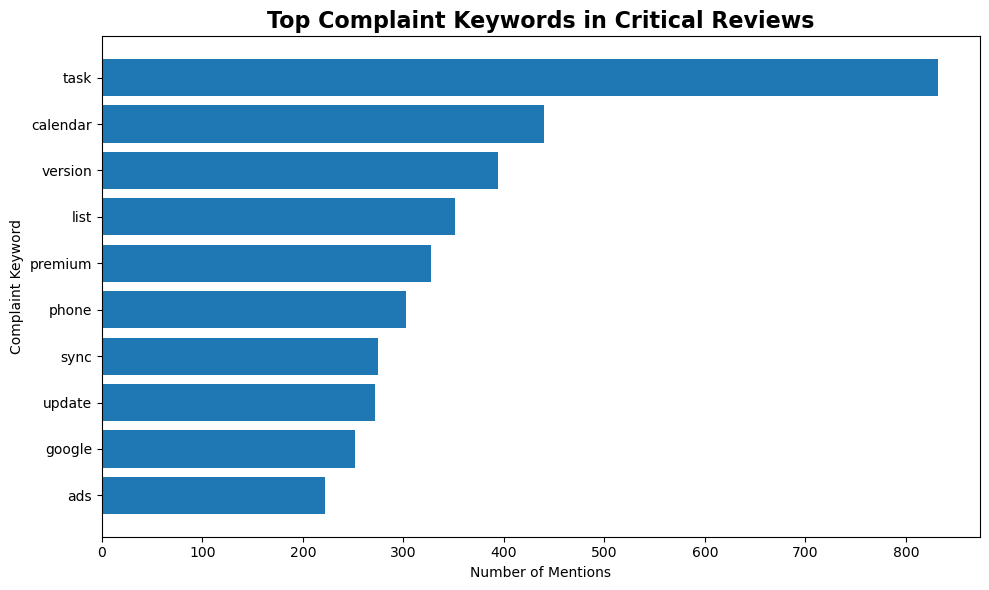

In [226]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_complaints_df['Complaint Keyword'][::-1],
    top_complaints_df['Frequency'][::-1]
)

plt.title(
    'Top Complaint Keywords in Critical Reviews',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Number of Mentions')
plt.ylabel('Complaint Keyword')

plt.tight_layout()
plt.show()

## Inference

Task-related terms are the most frequently mentioned in critical reviews, followed by calendar, version, list, and premium-related terms. This suggests that critical feedback is concentrated around core task-management functionality, calendar integration, app versions/updates, and premium features.

## Insight

The company should prioritize improvements to task and calendar functionality, while also investigating issues related to app updates, synchronization, premium features, and advertisements.

# Final Conclusion

The analysis shows that critical customer feedback is mainly associated with core application functionality and related user experience issues. Task management and calendar-related terms are the most frequently mentioned topics, followed by app versions, task lists, premium features, phone-related issues, synchronization, updates, Google integration, and advertisements.

A rule-based approach was used to identify critical reviews based on 1–2 star ratings without using Machine Learning. The three most detailed critical reviews were then selected for automated customer outreach.

Generative AI was used to create personalized and empathetic responses for each selected review. This demonstrates how rule-based filtering and Generative AI can work together to help customer-support teams prioritize critical feedback and reduce the manual effort required to draft responses.m